# Week — Logistic Regression & Feature Scaling

Comparing the effect of different scaling methods on logistic regression across three healthcare datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

## Load Data

In [2]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

print(df1.shape, df2.shape, df3.shape)

(433323, 19) (101766, 123) (5109, 18)


## Helper Functions

In [3]:
CONTINUOUS = {
    'df1': ['_BMI5', 'MENTHLTH', 'PHYSHLTH'],
    'df2': ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses'],
    'df3': ['age', 'avg_glucose_level', 'bmi']
}

def prep(df, target, drop_cols=[]):
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]
    mask = y.notna() & X.notna().all(axis=1)
    return X[mask], y[mask]

def split_scale(X, y, cont_cols, scaler):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_test = X_train.astype(float).copy(), X_test.astype(float).copy()
    cols = [c for c in cont_cols if c in X_train.columns]
    X_train[cols] = scaler.fit_transform(X_train[cols])
    X_test[cols]  = scaler.transform(X_test[cols])
    return X_train, X_test, y_train, y_test

def evaluate(model, X_test, y_test, label):
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f'\n--- {label} ---')
    print(classification_report(y_test, pred))
    print(confusion_matrix(y_test, pred))
    auc = roc_auc_score(y_test, prob)
    print(f'AUC: {auc:.4f}')
    return prob, auc

def plot_roc(y_test, results, title):
    plt.figure(figsize=(8, 5))
    for label, prob in results.items():
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(title); plt.legend(fontsize=9)
    plt.tight_layout(); plt.show()

## Scaling Methods

| Scaler | How it works | Good for |
|---|---|---|
| StandardScaler | Subtracts mean, divides by std (z-score) | Most cases; assumes roughly normal distribution |
| MinMaxScaler | Scales to [0, 1] range | When you want bounded output; sensitive to outliers |
| RobustScaler | Uses median and IQR instead of mean/std | Data with outliers |

Logistic regression uses gradient descent under the hood, so unscaled features with very different ranges can cause slow convergence or unstable coefficients.

---
## Dataset 1 — Diabetes (`DIABETE4`)

In [4]:
df1_model = df1[df1['DIABETE4'].isin([0,1])].copy()
X1, y1 = prep(df1_model, target='DIABETE4', drop_cols=['_RFCHOL3'])

# split once (same split for all scalers)
X1_train_raw, X1_test_raw, y1_train, y1_test = train_test_split(
    X1.astype(float), y1, test_size=0.2, random_state=42, stratify=y1)

print(X1_train_raw.shape, X1_test_raw.shape)
print(y1.value_counts(normalize=True).round(3))

(220707, 17) (55177, 17)
DIABETE4
0.0    0.856
1.0    0.144
Name: proportion, dtype: float64


In [5]:
# No scaling baseline
lr1_none = LogisticRegression(max_iter=1000).fit(X1_train_raw, y1_train)
prob1_none, auc1_none = evaluate(lr1_none, X1_test_raw, y1_test, 'DF1 No Scaling')


--- DF1 No Scaling ---
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     47259
         1.0       0.53      0.15      0.23      7918

    accuracy                           0.86     55177
   macro avg       0.70      0.56      0.58     55177
weighted avg       0.82      0.86      0.82     55177

[[46241  1018]
 [ 6754  1164]]
AUC: 0.8169


In [6]:
# StandardScaler
cols1 = [c for c in CONTINUOUS['df1'] if c in X1_train_raw.columns]

X1_train_std, X1_test_std = X1_train_raw.copy(), X1_test_raw.copy()
scaler_std1 = StandardScaler()
X1_train_std[cols1] = scaler_std1.fit_transform(X1_train_raw[cols1])
X1_test_std[cols1]  = scaler_std1.transform(X1_test_raw[cols1])

lr1_std = LogisticRegression(max_iter=1000).fit(X1_train_std, y1_train)
prob1_std, auc1_std = evaluate(lr1_std, X1_test_std, y1_test, 'DF1 StandardScaler')


--- DF1 StandardScaler ---
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     47259
         1.0       0.53      0.15      0.23      7918

    accuracy                           0.86     55177
   macro avg       0.70      0.56      0.58     55177
weighted avg       0.82      0.86      0.82     55177

[[46239  1020]
 [ 6752  1166]]
AUC: 0.8169


In [7]:
# MinMaxScaler
X1_train_mm, X1_test_mm = X1_train_raw.copy(), X1_test_raw.copy()
scaler_mm1 = MinMaxScaler()
X1_train_mm[cols1] = scaler_mm1.fit_transform(X1_train_raw[cols1])
X1_test_mm[cols1]  = scaler_mm1.transform(X1_test_raw[cols1])

lr1_mm = LogisticRegression(max_iter=1000).fit(X1_train_mm, y1_train)
prob1_mm, auc1_mm = evaluate(lr1_mm, X1_test_mm, y1_test, 'DF1 MinMaxScaler')


--- DF1 MinMaxScaler ---
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     47259
         1.0       0.53      0.15      0.23      7918

    accuracy                           0.86     55177
   macro avg       0.70      0.56      0.58     55177
weighted avg       0.82      0.86      0.82     55177

[[46243  1016]
 [ 6755  1163]]
AUC: 0.8168


In [8]:
# RobustScaler
X1_train_rob, X1_test_rob = X1_train_raw.copy(), X1_test_raw.copy()
scaler_rob1 = RobustScaler()
X1_train_rob[cols1] = scaler_rob1.fit_transform(X1_train_raw[cols1])
X1_test_rob[cols1]  = scaler_rob1.transform(X1_test_raw[cols1])

lr1_rob = LogisticRegression(max_iter=1000).fit(X1_train_rob, y1_train)
prob1_rob, auc1_rob = evaluate(lr1_rob, X1_test_rob, y1_test, 'DF1 RobustScaler')


--- DF1 RobustScaler ---
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     47259
         1.0       0.53      0.15      0.23      7918

    accuracy                           0.86     55177
   macro avg       0.70      0.56      0.58     55177
weighted avg       0.82      0.86      0.82     55177

[[46238  1021]
 [ 6753  1165]]
AUC: 0.8169


  Scaler      AUC
    None 0.816865
Standard 0.816883
  MinMax 0.816835
  Robust 0.816866


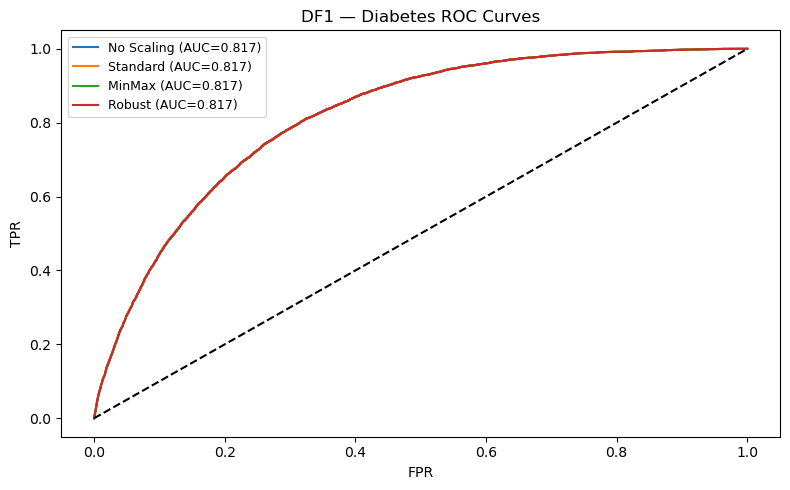

In [9]:
summary1 = pd.DataFrame({
    'Scaler': ['None', 'Standard', 'MinMax', 'Robust'],
    'AUC': [auc1_none, auc1_std, auc1_mm, auc1_rob]
})
print(summary1.to_string(index=False))

plot_roc(y1_test, {
    'No Scaling': prob1_none, 'Standard': prob1_std,
    'MinMax': prob1_mm, 'Robust': prob1_rob
}, 'DF1 — Diabetes ROC Curves')

---
## Dataset 2 — Hospital Readmission (`readmitted`)

In [10]:
X2, y2 = prep(df2, target='readmitted')

X2_train_raw, X2_test_raw, y2_train, y2_test = train_test_split(
    X2.astype(float), y2, test_size=0.2, random_state=42, stratify=y2)

cols2 = [c for c in CONTINUOUS['df2'] if c in X2_train_raw.columns]
print(X2_train_raw.shape, X2_test_raw.shape)

(238, 122) (60, 122)


In [11]:
lr2_none = LogisticRegression(max_iter=1000).fit(X2_train_raw, y2_train)
prob2_none, auc2_none = evaluate(lr2_none, X2_test_raw, y2_test, 'DF2 No Scaling')


--- DF2 No Scaling ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        53
           1       0.20      0.14      0.17         7

    accuracy                           0.83        60
   macro avg       0.55      0.53      0.54        60
weighted avg       0.81      0.83      0.82        60

[[49  4]
 [ 6  1]]
AUC: 0.5499


In [12]:
X2_train_std, X2_test_std = X2_train_raw.copy(), X2_test_raw.copy()
scaler_std2 = StandardScaler()
X2_train_std[cols2] = scaler_std2.fit_transform(X2_train_raw[cols2])
X2_test_std[cols2]  = scaler_std2.transform(X2_test_raw[cols2])

lr2_std = LogisticRegression(max_iter=1000).fit(X2_train_std, y2_train)
prob2_std, auc2_std = evaluate(lr2_std, X2_test_std, y2_test, 'DF2 StandardScaler')


--- DF2 StandardScaler ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        53
           1       0.20      0.14      0.17         7

    accuracy                           0.83        60
   macro avg       0.55      0.53      0.54        60
weighted avg       0.81      0.83      0.82        60

[[49  4]
 [ 6  1]]
AUC: 0.5418


In [13]:
X2_train_mm, X2_test_mm = X2_train_raw.copy(), X2_test_raw.copy()
scaler_mm2 = MinMaxScaler()
X2_train_mm[cols2] = scaler_mm2.fit_transform(X2_train_raw[cols2])
X2_test_mm[cols2]  = scaler_mm2.transform(X2_test_raw[cols2])

lr2_mm = LogisticRegression(max_iter=1000).fit(X2_train_mm, y2_train)
prob2_mm, auc2_mm = evaluate(lr2_mm, X2_test_mm, y2_test, 'DF2 MinMaxScaler')


--- DF2 MinMaxScaler ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        53
           1       0.00      0.00      0.00         7

    accuracy                           0.82        60
   macro avg       0.44      0.46      0.45        60
weighted avg       0.77      0.82      0.79        60

[[49  4]
 [ 7  0]]
AUC: 0.5984


In [14]:
X2_train_rob, X2_test_rob = X2_train_raw.copy(), X2_test_raw.copy()
scaler_rob2 = RobustScaler()
X2_train_rob[cols2] = scaler_rob2.fit_transform(X2_train_raw[cols2])
X2_test_rob[cols2]  = scaler_rob2.transform(X2_test_raw[cols2])

lr2_rob = LogisticRegression(max_iter=1000).fit(X2_train_rob, y2_train)
prob2_rob, auc2_rob = evaluate(lr2_rob, X2_test_rob, y2_test, 'DF2 RobustScaler')


--- DF2 RobustScaler ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        53
           1       0.20      0.14      0.17         7

    accuracy                           0.83        60
   macro avg       0.55      0.53      0.54        60
weighted avg       0.81      0.83      0.82        60

[[49  4]
 [ 6  1]]
AUC: 0.5391


  Scaler      AUC
    None 0.549865
Standard 0.541779
  MinMax 0.598383
  Robust 0.539084


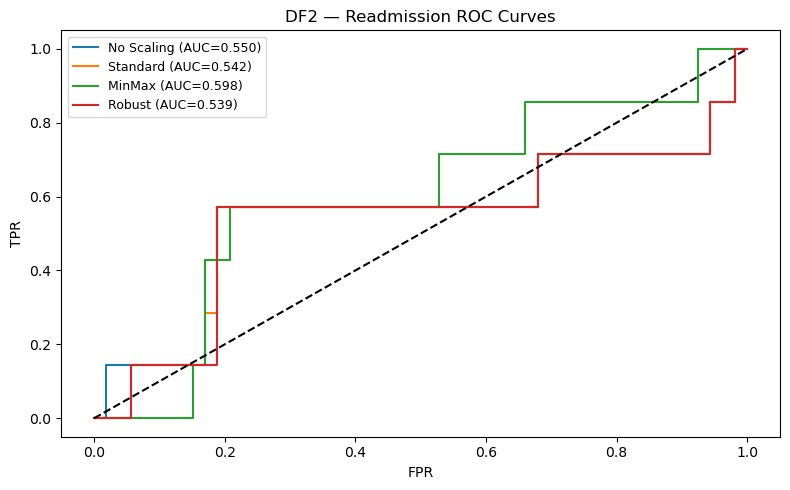

In [15]:
summary2 = pd.DataFrame({
    'Scaler': ['None', 'Standard', 'MinMax', 'Robust'],
    'AUC': [auc2_none, auc2_std, auc2_mm, auc2_rob]
})
print(summary2.to_string(index=False))

plot_roc(y2_test, {
    'No Scaling': prob2_none, 'Standard': prob2_std,
    'MinMax': prob2_mm, 'Robust': prob2_rob
}, 'DF2 — Readmission ROC Curves')

---
## Dataset 3 — Stroke (`stroke`)

> ~5% positive class — AUC is the right metric here.

In [16]:
X3, y3 = prep(df3, target='stroke')

X3_train_raw, X3_test_raw, y3_train, y3_test = train_test_split(
    X3.astype(float), y3, test_size=0.2, random_state=42, stratify=y3)

cols3 = [c for c in CONTINUOUS['df3'] if c in X3_train_raw.columns]
print(X3_train_raw.shape, X3_test_raw.shape)
print(y3.value_counts(normalize=True).round(3))

(4087, 17) (1022, 17)
stroke
0    0.951
1    0.049
Name: proportion, dtype: float64


In [17]:
lr3_none = LogisticRegression(max_iter=1000).fit(X3_train_raw, y3_train)
prob3_none, auc3_none = evaluate(lr3_none, X3_test_raw, y3_test, 'DF3 No Scaling')


--- DF3 No Scaling ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

[[972   0]
 [ 49   1]]
AUC: 0.8396


In [18]:
X3_train_std, X3_test_std = X3_train_raw.copy(), X3_test_raw.copy()
scaler_std3 = StandardScaler()
X3_train_std[cols3] = scaler_std3.fit_transform(X3_train_raw[cols3])
X3_test_std[cols3]  = scaler_std3.transform(X3_test_raw[cols3])

lr3_std = LogisticRegression(max_iter=1000).fit(X3_train_std, y3_train)
prob3_std, auc3_std = evaluate(lr3_std, X3_test_std, y3_test, 'DF3 StandardScaler')


--- DF3 StandardScaler ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

[[972   0]
 [ 49   1]]
AUC: 0.8394


In [19]:
X3_train_mm, X3_test_mm = X3_train_raw.copy(), X3_test_raw.copy()
scaler_mm3 = MinMaxScaler()
X3_train_mm[cols3] = scaler_mm3.fit_transform(X3_train_raw[cols3])
X3_test_mm[cols3]  = scaler_mm3.transform(X3_test_raw[cols3])

lr3_mm = LogisticRegression(max_iter=1000).fit(X3_train_mm, y3_train)
prob3_mm, auc3_mm = evaluate(lr3_mm, X3_test_mm, y3_test, 'DF3 MinMaxScaler')


--- DF3 MinMaxScaler ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

[[972   0]
 [ 49   1]]
AUC: 0.8384


In [20]:
X3_train_rob, X3_test_rob = X3_train_raw.copy(), X3_test_raw.copy()
scaler_rob3 = RobustScaler()
X3_train_rob[cols3] = scaler_rob3.fit_transform(X3_train_raw[cols3])
X3_test_rob[cols3]  = scaler_rob3.transform(X3_test_raw[cols3])

lr3_rob = LogisticRegression(max_iter=1000).fit(X3_train_rob, y3_train)
prob3_rob, auc3_rob = evaluate(lr3_rob, X3_test_rob, y3_test, 'DF3 RobustScaler')


--- DF3 RobustScaler ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

[[972   0]
 [ 49   1]]
AUC: 0.8394


  Scaler      AUC
    None 0.839609
Standard 0.839403
  MinMax 0.838416
  Robust 0.839383


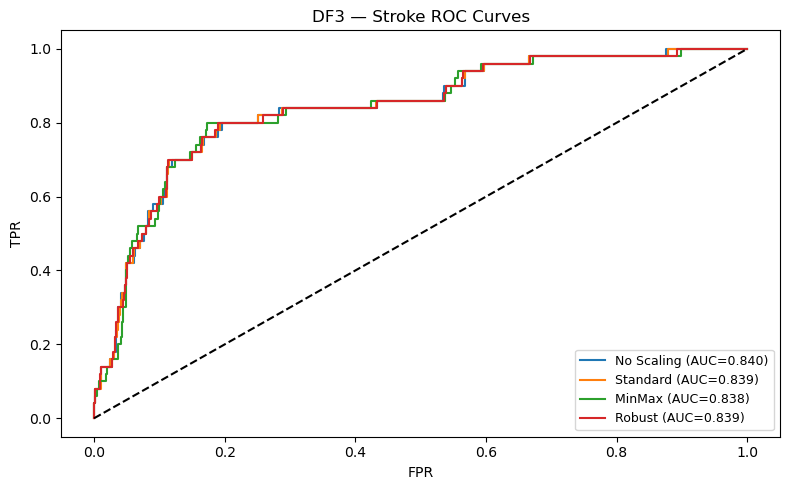

In [21]:
summary3 = pd.DataFrame({
    'Scaler': ['None', 'Standard', 'MinMax', 'Robust'],
    'AUC': [auc3_none, auc3_std, auc3_mm, auc3_rob]
})
print(summary3.to_string(index=False))

plot_roc(y3_test, {
    'No Scaling': prob3_none, 'Standard': prob3_std,
    'MinMax': prob3_mm, 'Robust': prob3_rob
}, 'DF3 — Stroke ROC Curves')

---
## Final Summary

          DF1 Diabetes  DF2 Readmission  DF3 Stroke
Scaler                                             
None            0.8169           0.5499      0.8396
Standard        0.8169           0.5418      0.8394
MinMax          0.8168           0.5984      0.8384
Robust          0.8169           0.5391      0.8394


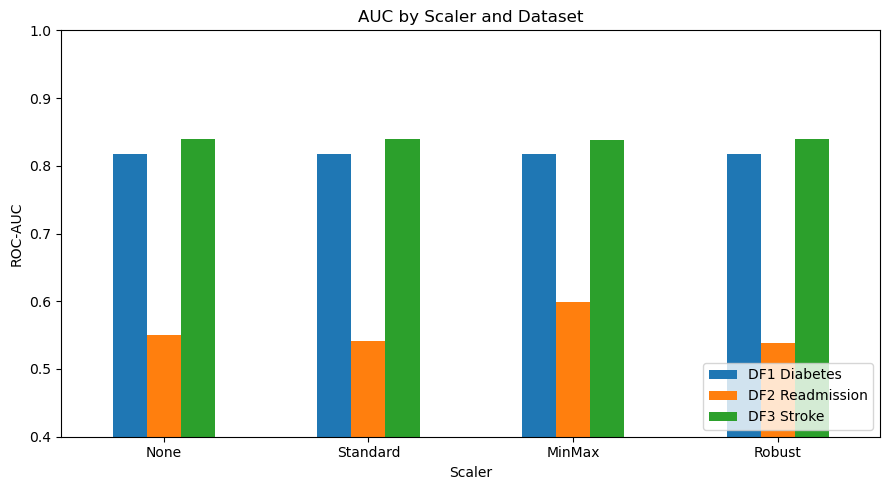

In [22]:
summary_all = pd.DataFrame({
    'Scaler': ['None', 'Standard', 'MinMax', 'Robust'],
    'DF1 Diabetes':    [auc1_none, auc1_std, auc1_mm, auc1_rob],
    'DF2 Readmission': [auc2_none, auc2_std, auc2_mm, auc2_rob],
    'DF3 Stroke':      [auc3_none, auc3_std, auc3_mm, auc3_rob],
}).set_index('Scaler').round(4)

print(summary_all.to_string())

summary_all.plot(kind='bar', figsize=(9, 5), ylim=(0.4, 1.0))
plt.title('AUC by Scaler and Dataset')
plt.ylabel('ROC-AUC'); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()